   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

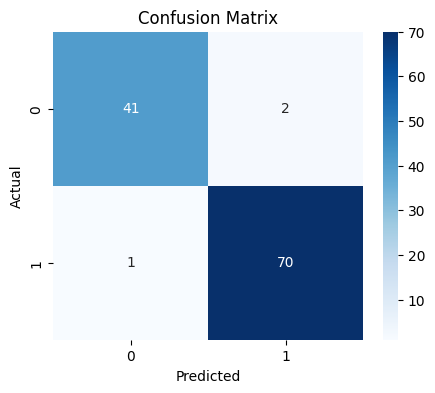

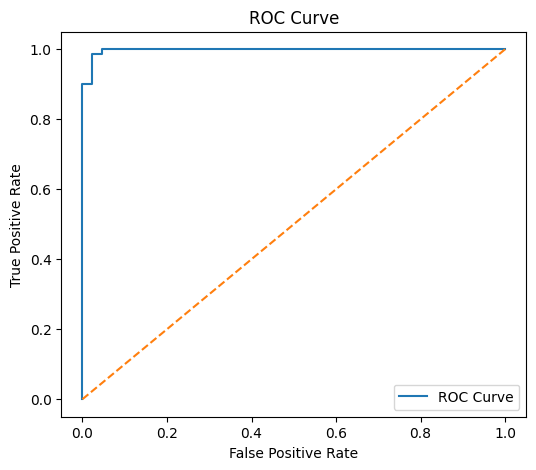

ROC-AUC Score: 0.99737962659679
Threshold: 0.4
[[41  2]
 [ 0 71]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



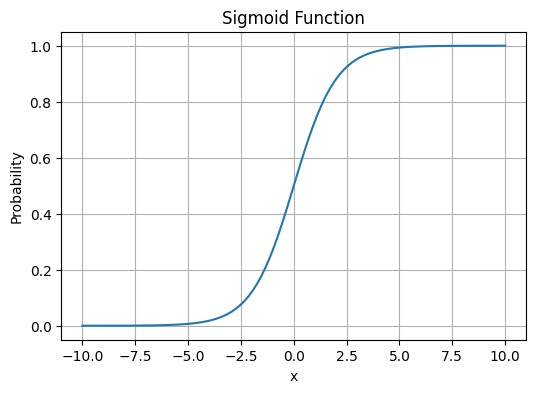

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,precision_score,recall_score,roc_curve,roc_auc_score

data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target)

print(X.head())
print(y.head())
print("Shape of Features:",X.shape)
print("Shape of Target:",y.shape)
print("Target Classes:")
print(y.value_counts())

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Accuracy:",model.score(X_test,y_test))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

y_prob=model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label="ROC Curve")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:",roc_auc_score(y_test,y_prob))

threshold=0.4
y_new=(y_prob>=threshold).astype(int)
print("Threshold:",threshold)
print(confusion_matrix(y_test,y_new))
print(classification_report(y_test,y_new))

x=np.linspace(-10,10,100)
sigmoid=1/(1+np.exp(-x))
plt.figure(figsize=(6,4))
plt.plot(x,sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Probability")
plt.grid(True)
plt.show()